<a href="https://colab.research.google.com/github/Maria-SG25/ENIAC-Discount-Strategy-Analysis/blob/main/ENIAC_discount_strategy_25_01_2026_final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Searching for the category

# **ENIAC — Discount Strategy Analysis**
This notebook explores key business questions about ENIAC’s pricing and discount strategy using cleaned and standardized e-commerce data with a business-focused approach.


# **🎯 Business Objective**

As a premium electronics retailer, ENIAC faces a strategic challenge:

Marketing seeks to increase sales through discounts.
Management and investors aim to protect profitability and maintain the company's premium brand image.
This project evaluates whether discounts create sustainable business value or simply reduce profit margins without significantly increasing revenue.

# **🧹 Data Preparation**

Before performing the analysis, the dataset was cleaned and standardized to ensure reliable results.

The data preparation process included:

Handling missing and inconsistent values
Removing invalid and incomplete orders
Standardizing date and pricing formats
Consolidating product categories
Keeping only completed customer transactions
These steps improved data quality and ensured consistency throughout the analysis.

# Challenge. The categories
 We'll reset the Dataframe so that no categories exist, and it's up to you to create the categories based on keywords in the name and description. Feel free to go wild and make as many categories as you like.
* Remember you can also use regex to refine your searches.
* Remember you can use the or operator `|` to search for multiple terms at once.
* Remember to tidy up any untidy strings at the end.

In [2]:
import pandas as pd

# orders_qu.csv
url = "https://drive.google.com/file/d/143CzG5DriVSPMkaL1UP4k3Y80oS8fgbV/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1yWO-mQfxQtnSZdCgdNlIEUrZSCW1HN5O/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands.csv
url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

product_category_df = products_cl.copy()

In [3]:
# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

product_category_df = products_cl.copy()

## **Categories code**


In [4]:
orders_qu.shape

(40985, 4)

In [5]:
 #   smartphone  ###CLEANED###
product_category_df.loc[
     (
       (product_category_df["name"].str.contains(
        r"iphone|galaxy|huawei|xiaomi|pixel|smartphone|Apple iPhone|Open - Apple iPhone |Like new - Apple iPhone ",
         case=False, na=False)
       | product_category_df["type"].astype(str).isin(['24821716', '51601716', '85641716', '24811716', '85651716','1716', '21571716', '21561716', '113291716', '113281716', '113271716'])
        )
      & (product_category_df["price"] > 400)
       )
 & ~product_category_df["type"].astype(str).isin([
      "11865403","11905404","1216","11935397","12215397","1229","1230","1231",     "12635403","12645406","1296","13005399","1325","13555403","13615399", "13855401","1424","1433","14365395","1515","21485407","5384","5395","5398", "5399","5403","5405","5407","5720","1,44E+11","5,49E+11","24215399", "12285400","9094"]),
     "category"
   ] = "smartphone"


In [6]:
#  laptop  ###CLEANED###
product_category_df.loc[(
      (
       product_category_df["name"].str.contains(
       r"laptop|notebook|macbook|thinkpad|ideapad|chromebook|MobileStudio Pro|Cintiq Companion|Apple MacBook Pro 15 ",
       case=False, na=False)
      | product_category_df["type"].astype(str).isin(["1,02E+12", "9,29E+11", '5,39E+11', "2,17E+11",'51902158'])
      )
        & (product_category_df["price"] > 1000)
      )
       & ~ product_category_df["type"].astype(str).isin(["1392","11935397","13005399","13835403","14305406", "54085407", "13855401",'12355400',"20642062", "13835403","13835403", "1325", "8696", "10230", "57445397", "5403", "12585395", "10142", "1229", "12995397","12755395", "1433", "12215397","12655397", "1515", "1231", '1405']),
      "category"
  ] = "laptop"


In [7]:
#   tablet  ###CLEANED###
product_category_df.loc[
    (
    (product_category_df["name"].str.contains(
        r"ipad|tablet|galaxy tab|surface|Graphics Tablet|Wacom Cintiq|Apple iPad Pro |Apple iPad Wi-Fi",
        case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1405", "106431714"])
    )
    & (product_category_df["price"] >=239)
    )
    &  ~product_category_df["type"].astype(str).isin(["1,44E+11", "12085400", "8696","14035403", "1216", "21535407", "5720", "12635403", "13835403", "1392", "1229", "13005399", "12575403", "10230", "101781405", "14305406", "12645406", "20642062", "54085407", "54025401" ,"13005399", "13855401", "13955395", "5403", "12285400", "13615399", '14365395', "11865403", "12051714"]),
    "category"
] = "tablet"


In [8]:
# networking  ###CLEANED###
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"router|wifi|modem|network|ethernet|dLAN|switch|adapter|D-Link|satellite|TP-Link|Airport|video recorder", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1334", "1325"])
    )
    & (~product_category_df["name"].astype(str).str.contains(r"\b(?:case|cable)\b",case=False, na=False)
)
    &  ~product_category_df["type"].astype(str).isin(["106431714", "1404", "24215399"]),
   "category"
] = "networking"


In [9]:
# wearable     ###CLEANED###
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"watch|smartwatch|fitbit|wearable|Apple Nike Sport|apple watch|galaxy watch|watch series|Steel Watch|virtual reality glasses|Apple Watch Series 2Fitbit|Jawbone|MyKronoz|Nokia Intelligent Activity|Pebble Smartwatch|iHealth|Withings Activite", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["24895185", "2449", "24885185", "5185"])
    )
    & (product_category_df["price"] >=129)
    )
     &  ~product_category_df["type"].astype(str).isin(["1515",'5405', '2449', "12282", "12285400", "2434", "24215399", '2425','11865403','13615399','12645406','12285400', '5384']),
    "category"
] = "wearable"


In [10]:
# audio  ###CLEANED###
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"headphone|earphone|earbuds|airpods|speaker|speakers|headset|iPod|audio|Beats|IK Multimedia|Blue Microphones|IK Multimedia iRig", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["5384","5398","1375"])
     )
    & (product_category_df["price"] >15)
    )
    &  ~product_category_df["type"].astype(str).isin(["1,44E+11", "12051714", "5405", "1515", "5720","1216", "14305406", "12645406", "12285400", "13615399", "1296", "21485407"]),
    "category"
] = "audio"


In [11]:
# camera_drone   ###CLEANED###
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"GoPro Hero|dslr|mirrorless|gopro|drone|dji|mavic|parrot|Parrot Drone|Mavic Pro|Kaiser Baas", case=False, na=False)

    )
      & (product_category_df["price"] >=89)
    )
    &  ~product_category_df["type"].astype(str).isin(["112355400", "5398"]),
    "category"
] = "camera_drone"


In [12]:
# storage & memory.  ###CLEANED###. from the cheapest flash card to NAS|server
#
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"\bssd\b|\bhdd\b|usb|raid|g-speed|g-technology|pegasus|5big|qnap|nas|drobo|iscsi|san|wd my cloud| hard drive|hard disc|flash drive|memory|sd card|WD|Seagate|SDHC|microSD|promise|My Book Pro|OWC|Express|Western Digital|Wacom Intuos|Kingston V300|anti-theft system|Enlargement Kit|EVO|Synology RackStation|SanDisk|Kingston|Crucial|OWC Aura SSD kits|Lacie d2 Thunderbolt|Synology NAS Server DS| WD Hard Drive|FCM Mac Memory| iAdapt|Synology RX1217 expansion|Synology Pack DS416J|Transcend JetDrive Lite ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["11935397","12585395", "12655397","12755395","12995397","12215397","1280", "1276", "12175397","57445397", "1433", "1364", "42945397"])
    )
    &  ~product_category_df["type"].astype(str).isin(["1,02E+12", "5,39E+11", "2,16E+11", "9,29E+11", "13955395","14305406", "14365395", "15435404", "1282", "21632158", "1405", "1325", "1230", "5398", "1387", "118692158", "2,17E+11","1375","1,44E+11", "1334", "24895185"]),
    "category"
] =  "storage & memory"


In [13]:
## accessory (to all the categories) ###CLEANED###
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"case|cover|charger|cable|keyboard|stand|hub|correa|stylus|power bank|logitech mouse|usb mouse|powerstation|bracelet|belt|pointer|LaCie|powerCube|Wacom Bamboo|battery|Wacom Intuos|Crucial|kit|Minibatt|Belkin cable|\bcase\b|\bcover\b|\bcable\b|\bcharger\b|\badapter\b|\bkeyboard\b|\bmouse\b|\bstand\b|\bhub\| b\bram\b|memory|dimm|so-dimm|ddr3|ddr4|ecc|Screen Protector|Leather Folio|Housing|Apple Pencil|iPhone Folio|Support Kukaclip car|Belkin Car Charger|Logitech|iOttie Easy|Zagg |Twelve South|Startech|SecurityXtra|MIXIT Belkin Car Charge|Tucano tugo|Leather|Thule|OWC In-line Digital Temperature|Synology Rail Kit|Sliding Rail|SwitchEasy iPhone Case|Tempered glass|Protector InvisiGlass|protector|I AM Cardboard|Mujjo Single-Layered|Muvit|NewerTech NuTouch|Olloclip 4-in-1|Polaroid ZINK|Prynt|Utopia Retrak 360 card|ZIP Polaroid Mobile| Classic Belkin|Griffin Survivor|Mediterrans cover|Twelve South|Speck SeeThru|Urban Armor Gear| Adonith| Air Protect SheerForce|Be.ez|Wacom Intuos|Waterproof| Moshi| Satechi|Speck ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["11865403", "12635403", "13835403", "13835403", "8696", "14035403", "1515", "13615299", "1335", "1229", "13555403","12355400", "13955395", "14365395", "1216", "12585395", "12645403", "5395", "5405", "5403","1230", "1387","10142", "10230", "5720", "13855401", "12085400","1392", "13005399","1325", "2425", "54864259", "12755395", "2449","5399","1405", "1424", "13615399", "24215399", "12282", "5384", "9094", "12285400"])
    )
    &  ~product_category_df["type"].astype(str).isin(["1,02E+12", "24895185", "1282", "12215397", "11935397" ,"1364","9,29E+11", "24885185", "1433", "12995397", "12655397","1276", "1334", "1405","42945397","5185", "5398", "57445397","1,44E+11", "4259", "14305406","15435404","21485407","54085407", "12645406","NaN"]),
    "category"
] = "accessory"


In [14]:
# software   ###CLEANED###
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"software|license|subscription|antivirus|office 365|AppleCare|edition|quarkxpress|office|adobe", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1416"])
    )
    &  ~product_category_df["type"].astype(str).isin(["11935397","1405","11905404","11865403","1229","1298", "2449","5399", "12175397","12995397"
  ]),
    "category"
] = "software"


In [15]:
# smart_home       ###CLEANED###
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"smart home|alexa|google home|echo|nest|sensor|smart bulb|smart plug|philips hue|scale|ThermoPeanut|GuardPeanut| Withings Home|Ninebot by Segway", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["9094"])
    )
    &  ~product_category_df["type"].astype(str).isin(["15435404", "1276", "21485407"]),
    "category"
] = "smart_home"


In [16]:
#  desktop_professional_hardware"        ###CLEANED###
product_category_df.loc[
    (
    product_category_df["name"].str.contains(r"apple iMac|apple imac pro|apple mac pro|apple mac mini|workstation|Synology RX1217RP|Docking Station|Griffin Multidock ", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1282", "5,74E+15", "1,02E+12", "2158", "2,16E+11", "21632158"])
    )
    & ~product_category_df["type"].astype(str).isin(["12755395", "1280", "8696", "11935397", "12175397", "12655397", "12995397", "1276","1334", "12585395"]),
    "category"
] = "desktop_professional_hardware"


In [17]:
#   tv_monitor  ###CLEANED###
product_category_df.loc[(
    (
    product_category_df["name"].str.contains(r"tv|television|monitor|screen|dell|display|LED Monitor|LCD Monitor|Open - Dell|Open - LG", case=False, na=False)
    | product_category_df["type"].astype(str).isin(["1296", "113464259", "4259"])
    )
       & (product_category_df["price"] >= 100)
    )
    &  ~product_category_df["type"].astype(str).isin(["113464259", "11865403", "1216","12355400", "13555403", "12085400", "12585395", "1405", "12175397", "1282", "12635403","12285400", "13005399", "1325", "14035403", "2425", "54864259", "5398", "8696", "9094", "1,44E+11", "1231", "12645406", "21485407", "13835403", "1334", "4259", "5395"]),
    "category"
] = "tv_monitor"


In [18]:
product_category_df["category"] = (
    product_category_df["category"]
    .fillna("other")
    .str.strip()
    .str.lower()
)

In [19]:
product_category_df["category"].value_counts()


,count
category,
accessory,4062
storage & memory,2655
desktop_professional_hardware,1064
other,541
audio,285
smartphone,261
tv_monitor,252
tablet,221
smart_home,174


In [20]:
# to check categories (for internal use)
check = product_category_df.loc[product_category_df['category']== "other"]
check

,sku,name,desc,price,in_stock,type,category
32,BEL0070,Music Receiver Belkin iPhone music receiver,Music Receiver iPhone iPad and iPod Touch for ...,49.99,0,11905404,other
78,APP0370,Apple TV media player,Apple multimedia player.,79.00,0,4259,other
147,NTE0044,"NewerTech windy 225 ""for iMac",Suction cup 225 inches for aluminum iMac.,11.99,1,14305406,other
161,OWC0028,"OWC SSD installation Kit for iMac 215 ""(2011)",Installation kit for iMac SSD 215 inches (2011).,60.99,1,14305406,other
162,OWC0013,OWC Kit of 5 tools for Mac and PC,Kit of 5 tools for repair / extension Mac.,6.99,1,14305406,other
...,...,...,...,...,...,...,...
9979,REP0412,Rear Camera Repair iPhone 7 Plus,It is including parts and labor for iPhone 7 Plus,119.99,0,"1,44E+11",other
9981,REP0418,iPhone charging connector repair,Repair service including parts and labor for i...,49.99,0,"1,44E+11",other
9983,REP0403,iPad LCD screen repair,Repair service including parts and labor for iPad,159.99,0,"1,44E+11",other
9984,REP0402,iPad touch screen repair,Repair service including parts and labor for iPad,139.99,0,"1,44E+11",other


In [21]:
mask_phone = products_cl["name"].astype(str).str.contains(
    r"(?i)\bapple\s+iphone\b.*\b\d+\s*gb\b",
    regex=True
)
Phone_df = products_cl.loc[mask_phone]
Phone_df

,sku,name,desc,price,in_stock,type
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.00,0,NaN
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.00,0,NaN
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.00,0,NaN
...,...,...,...,...,...,...
9788,AP20453,Like new - Apple iPhone 7 256GB Black Bright,Apple iPhone 7 256GB refitted in Black Bright ...,990.33,0,85641716
9789,AP20454,Like new - Apple iPhone 8 256GB Silver,Apple iPhone 8 refitted in Silver 256GB ready ...,979.00,0,113291716
9790,AP20455,Like new - Apple iPhone 8 256GB Gold,Apple iPhone 8 reconditioned 256GB in Gold rea...,979.00,0,113291716
9794,APP2482-A,Open - Apple iPhone 8 Plus 256GB Gold,Refurbished Apple iPhone 8 Plus 256GB Free Gold,1089.00,0,113281716


In [22]:
# to check which types belong to each category (for internal use)
product_category_df.loc[product_category_df["category"] == "smartphone", "type"].unique()


array([nan, '24821716', '51601716', '85641716', '24811716', '85651716',
       '1298', '1716', '21571716', '21561716', '113291716', '113281716',
       '113271716'], dtype=object)

In [23]:
product_category_df.columns

Index(['sku', 'name', 'desc', 'price', 'in_stock', 'type', 'category'], dtype='object')

# 1. Product Distribution

In [24]:
price_distribution = (
    product_category_df
    .groupby("category")["price"]
    .agg(["count", "min", "median", "max"])
    .rename(columns={
        "count": "Number of products",
        "min": "Cheapest product",
        "median": "Median price",
        "max": "Most expensive product"
    })
    .round()
    .sort_values("Median price", ascending=False)
)

price_distribution

,Number of products,Cheapest product,Median price,Most expensive product
category,,,,
desktop_professional_hardware,1064,80.0,2799.0,15339.0
laptop,93,1099.0,1799.0,3200.0
tablet,221,239.0,789.0,3200.0
smartphone,261,409.0,769.0,1329.0
wearable,162,130.0,419.0,1269.0
storage & memory,2655,4.0,375.0,10213.0
tv_monitor,252,105.0,359.0,2550.0
software,37,29.0,249.0,1600.0
camera_drone,44,89.0,160.0,1499.0


/tmp/ipython-input-3891769833.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['price'] = df_plot['price'].clip(q_low, q_high)


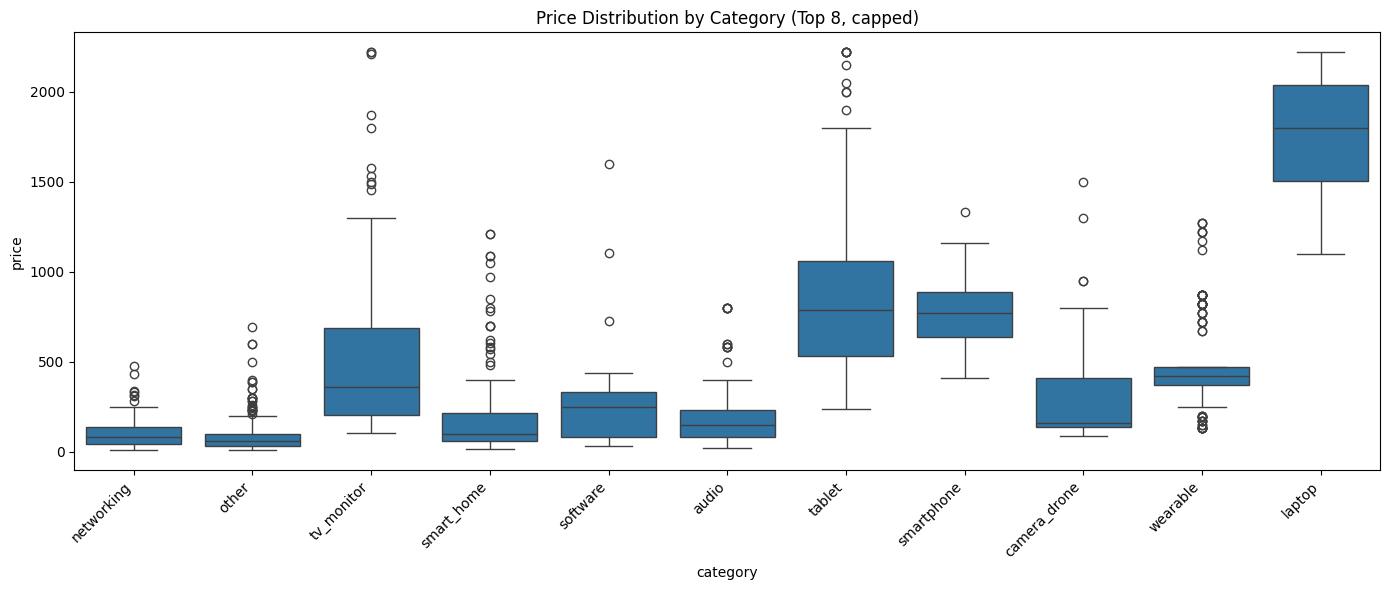

In [ ]:
top_categories = (
    product_category_df['category']
    .value_counts()
    .tail(11)
    .index
)

df_plot = product_category_df[
    product_category_df['category'].isin(top_categories)
]

# Cap prices
q_low, q_high = df_plot['price'].quantile([0.01, 0.99])
df_plot['price'] = df_plot['price'].clip(q_low, q_high)

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_plot, x='category', y='price')
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Category (Top 8, capped)')
plt.tight_layout()
plt.show()

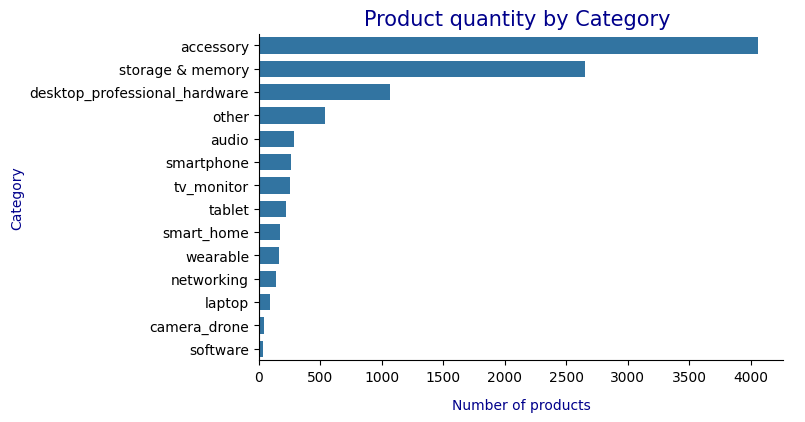

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    kind="count",
    data=product_category_df,
    y="category",
    order=product_category_df["category"].value_counts().index,
    width=0.7,
    height=4,
    aspect=2
)
plt.title("Product quantity by Category ", color = "darkblue", fontsize=15)
plt.xlabel("Number of products", color = "darkblue", fontsize=10, labelpad = 10)
plt.ylabel("Category", color = "darkblue", fontsize=10)
plt;

In [ ]:
# Convert date
orders_qu["created_date"] = pd.to_datetime(orders_qu["created_date"])

# Merge orderlines + orders
sales_df = (
    orderlines_qu
    .merge(
        orders_qu[["order_id", "created_date", "state"]],
        left_on="id_order",
        right_on="order_id",
        how="inner"
    )
)


# 2. Discount Strategy

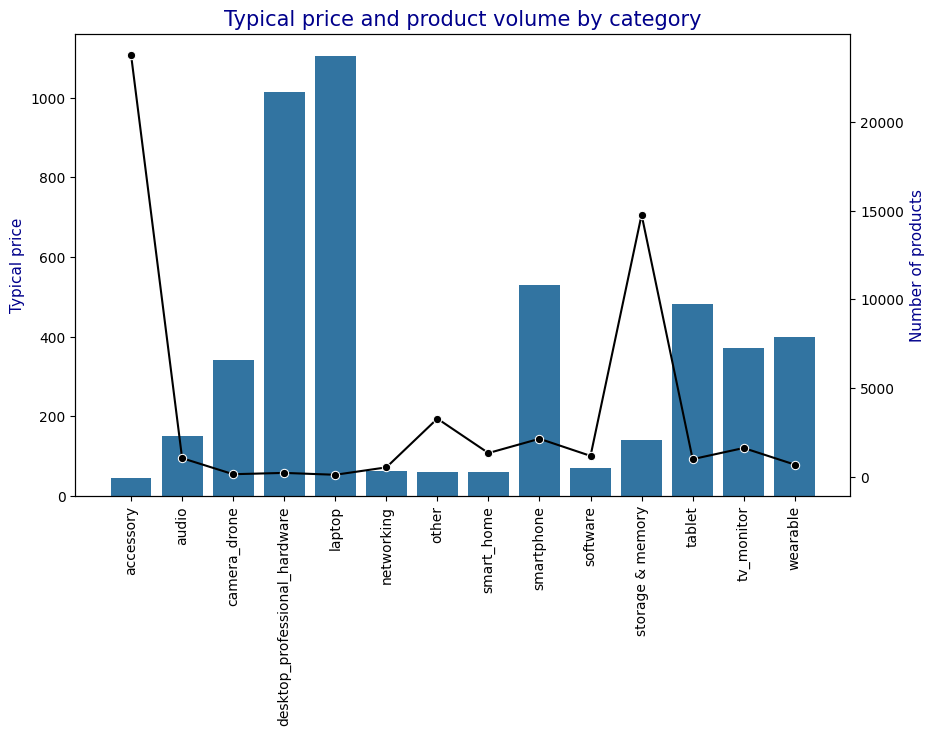

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart: median price
sns.barplot(
    data=summary,
    x="category",
    y="median_price",
    ax=ax1
)

ax1.set_ylabel("Typical price",  color = "darkblue", fontsize = 11)
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=90)

# Line chart: product count
ax2 = ax1.twinx()
sns.lineplot(
    data=summary,
    x="category",
    y="product_count",
    ax=ax2,
    marker="o",
    color="black"
)

ax2.set_ylabel("Number of products",  color = "darkblue", fontsize = 11)

plt.title("Typical price and product volume by category", color = "darkblue", fontsize = 15)
plt.show()


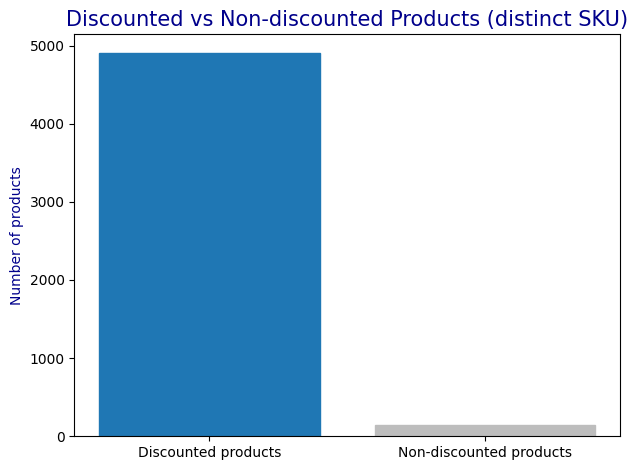

In [ ]:
products_summary = pd.DataFrame({
    "Product type": ["Discounted products", "Non-discounted products"],
    "Count": [discounted_products, non_discounted_products]
})

products_summary
import matplotlib.pyplot as plt

# Plot with individual bar colors
fig, ax = plt.subplots()

bars = ax.bar(
    products_summary["Product type"],
    products_summary["Count"]
)

# Set colors manually
bars[0].set_color("#1f77b4")   # blue → discounted
bars[1].set_color("#bdbdbd")   # grey → non-discounted

ax.set_title("Discounted vs Non-discounted Products (distinct SKU)",color="darkblue", fontsize = 15)
ax.set_ylabel("Number of products", color="darkblue", fontsize = 10)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

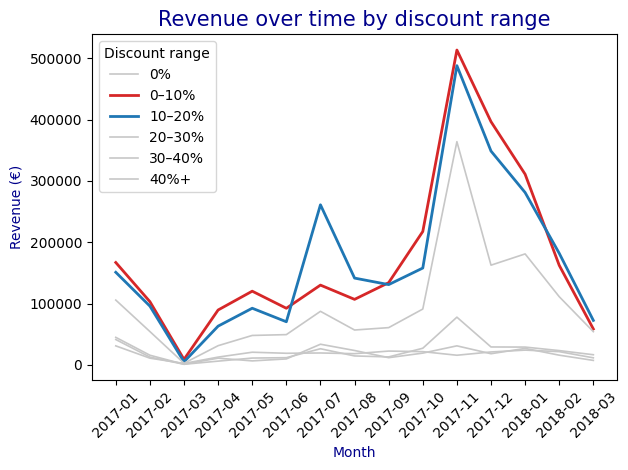

In [ ]:
import matplotlib.pyplot as plt


discount_range = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]

fig, ax = plt.subplots()

for dr in discount_range:
    subset_df = revenue_time_discount[
        revenue_time_discount["discount_range"] == dr
    ]

    if dr == "0–10%":
        ax.plot(
            subset_df["month"].astype(str),
            subset_df["revenue"],
            label=dr,
            color="#d62728",   # red
            linewidth=2
        )
    elif dr == "10–20%":
        ax.plot(
            subset_df["month"].astype(str),
            subset_df["revenue"],
            label=dr,
            color="#1f77b4",   # blue
            linewidth=2
        )
    else:
        ax.plot(
           subset_df["month"].astype(str),
            subset_df["revenue"],
            label=dr,
            color="#c7c7c7",   # grey
            linewidth=1.2
        )


ax.set_title("Revenue over time by discount range", color = "darkblue", fontsize = 15)
ax.set_xlabel("Month", color = "darkblue", fontsize = 10)
ax.set_ylabel("Revenue (€)", color= "darkblue", fontsize = 10)
ax.legend(title="Discount range")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["discount_range"] = None

df.loc[df["discount_pct"] == 0, "discount_range"] = "0%"
df.loc[(df["discount_pct"] > 0) & (df["discount_pct"] < 10), "discount_range"] = "0–10%"
df.loc[(df["discount_pct"] >= 10) & (df["discount_pct"] < 20), "discount_range"] = "10–20%"
df.loc[(df["discount_pct"] >= 20) & (df["discount_pct"] < 30), "discount_range"] = "20–30%"
df.loc[(df["discount_pct"] >= 30) & (df["discount_pct"] < 40), "discount_range"] = "30–40%"
df.loc[df["discount_pct"] >= 40, "discount_range"] = "40%+"


discount_distribution = (
    df["discount_range"]
    .value_counts()
    .reindex(["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"])
)

discount_distribution

,count
discount_range,
0%,2423
0–10%,10336
10–20%,14951
20–30%,11694
30–40%,4585
40%+,7778


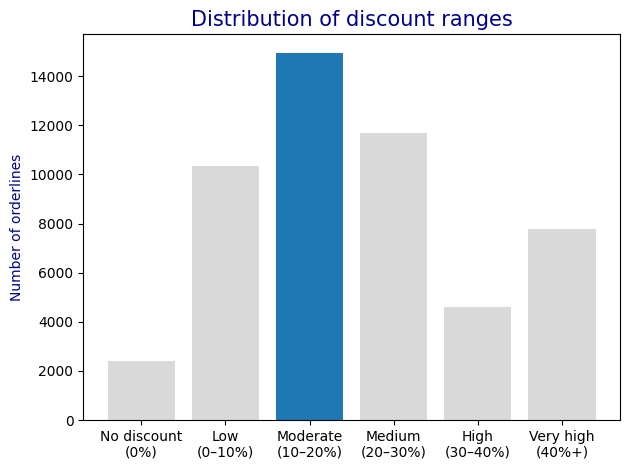

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Order and business labels
order = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]
business_labels = [
    "No discount\n(0%)",
    "Low\n(0–10%)",
    "Moderate\n(10–20%)",
    "Medium\n(20–30%)",
    "High\n(30–40%)",
    "Very high\n(40%+)"
]

dist = discount_distribution.reindex(order)

# Highlight Moderate (10–20%) in blue
colors = ["#d9d9d9", "#d9d9d9", "#1f77b4", "#d9d9d9", "#d9d9d9", "#d9d9d9"]

fig, ax = plt.subplots()
ax.bar(range(len(dist)), dist.values, color=colors)

ax.set_title("Distribution of discount ranges",color="darkblue", fontsize = 15)
ax.set_ylabel("Number of orderlines",color="darkblue", fontsize = 10)

# Apply business labels
ax.set_xticks(range(len(order)))
ax.set_xticklabels(business_labels)

plt.tight_layout()
plt.show()


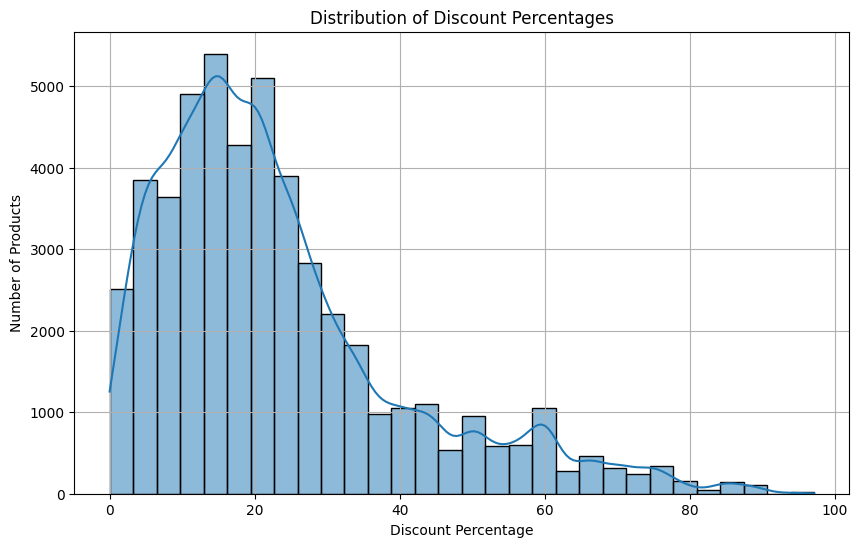

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(discounted_products['discount_percentage'], bins=30, kde=True)
plt.title('Distribution of Discount Percentages')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.grid(True)
plt.show()

Most orderlines fall within the moderate discount range, making it the most frequently used discount level across all transactions.

Low discounts are also widely applied, suggesting that small price reductions are a common tactic to stimulate purchases.

Orders without any discount represent a relatively small share, indicating that discounting is a standard practice rather than an exception.

High discount ranges (30% and above) are less frequent, showing that aggressive discounting is used selectively rather than as a regular strategy.

Low discounts (0–10%) generate the highest and most stable revenue over time, indicating they are the most effective at increasing sales while preserving value.

Moderate discounts (10–20%) create noticeable but short-term revenue peaks, often linked to promotional periods, but are less consistent than low discounts.

High discounts (20% and above) contribute only marginally to total revenue, despite sometimes driving a high number of transactions, showing a volume effect rather than value creation.

The strong end-of-year revenue peak is mainly driven by low and moderate discounts, suggesting that seasonality amplifies the impact of efficient discount strategies rather than aggressive price cuts.

0–10% discount range:
✔️ Highest revenue
✔️ Relatively high margin

Above 20% discounts:
❌ Low revenue
❌ Low margin
👉 High-risk zone

# 3. Revenue and Margin Analysis

In [ ]:
# Merge orderlines (+ products df) with orders
sales_df = df.merge(
    orders_qu[["order_id", "created_date"]],
    left_on="id_order",     # in orderlines/df
    right_on="order_id",    # in orders
    how="left"
)

# Convert date
sales_df["created_date"] = pd.to_datetime(sales_df["created_date"])

# Create month
sales_df["month"] = sales_df["created_date"].dt.to_period("M").astype(str)

sales_df[["id_order", "order_id", "created_date", "month"]].head()


,id_order,order_id,created_date,month
0,299545,299545,2017-01-01 01:51:47,2017-01
1,299546,299546,2017-01-01 01:57:34,2017-01
2,295347,295347,2017-01-01 02:02:38,2017-01
3,299556,299556,2017-01-01 02:30:08,2017-01
4,299561,299561,2017-01-01 02:39:47,2017-01


In [ ]:
sales_df["revenue"] = (
    sales_df["unit_price"] * sales_df["product_quantity"]
)
sales_df["month"] = sales_df["created_date"].dt.to_period("M")
sales_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,category,price,discount_pct,discount_range,order_id,created_date,month,revenue
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,smart_home,60.99,22.1,20–30%,299545,2017-01-01 01:51:47,2017-01,47.49
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,accessory,22.95,17.3,10–20%,299546,2017-01-01 01:57:34,2017-01,18.99
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,accessory,89.00,18.9,10–20%,295347,2017-01-01 02:02:38,2017-01,72.19
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,accessory,76.99,20.9,20–30%,299556,2017-01-01 02:30:08,2017-01,60.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,wearable,299.99,52.5,40%+,299561,2017-01-01 02:39:47,2017-01,142.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51762,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,accessory,25.00,60.0,40%+,527035,2018-03-14 11:44:34,2018-03,9.99
51763,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,accessory,25.00,60.0,40%+,527070,2018-03-14 11:50:48,2018-03,19.98
51764,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,accessory,25.00,60.0,40%+,527074,2018-03-14 11:51:42,2018-03,19.98
51765,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,accessory,25.00,60.0,40%+,527096,2018-03-14 11:58:40,2018-03,29.97


In [ ]:
Eniac_monthly_revenue = (
    sales_df
    .groupby("month")["revenue"]
    .sum()
    .round(1)
    .reset_index()
)

Eniac_monthly_revenue

,month,revenue
0,2017-01,540587.9
1,2017-02,292497.6
2,2017-03,20551.6
3,2017-04,213496.0
4,2017-05,298543.1
5,2017-06,252107.4
6,2017-07,557583.9
7,2017-08,361262.7
8,2017-09,372700.1
9,2017-10,534056.5


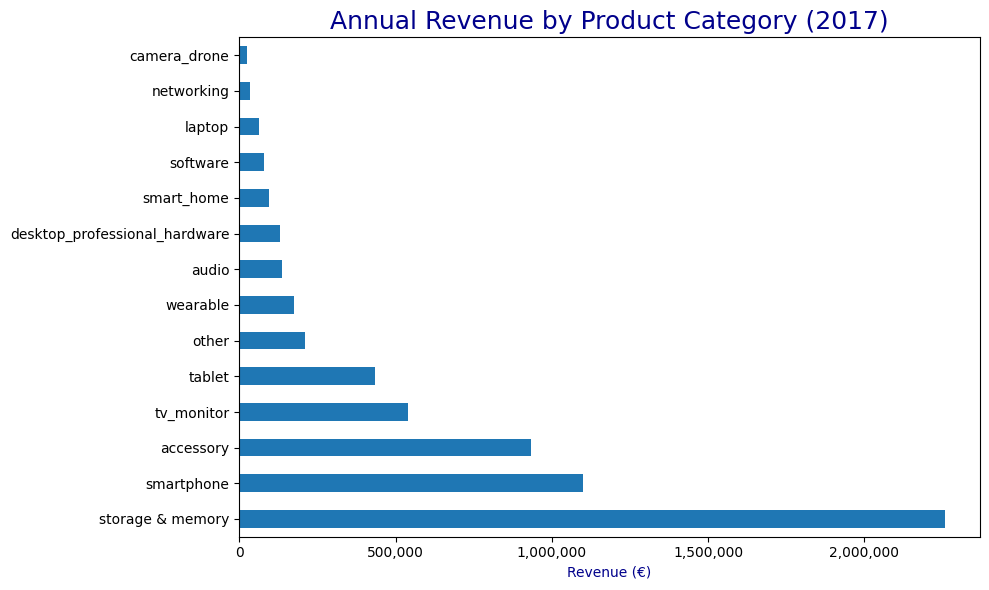

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


ax = annual_revenue_by_category.plot(
    kind="barh",
    figsize=(10,6),
    color = ["#1f77b4"],
)

ax.set_title(
    "Annual Revenue by Product Category (2017)",
    fontsize=18,
    color="darkblue"
)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x', labelsize=10)  # revenue values
ax.tick_params(axis='y', labelsize=10)
ax.set_xlabel("Revenue (€)",color="darkblue", fontsize = 10)
ax.set_ylabel("")

plt.tight_layout()
plt.show()



,month,revenue
0,2017-01,540587.9
1,2017-02,292497.6
2,2017-03,20551.6
3,2017-04,213496.0
4,2017-05,298543.1
5,2017-06,252107.4
6,2017-07,557583.9
7,2017-08,361262.7
8,2017-09,372700.1
9,2017-10,534056.5


In [ ]:
sales_df["margin_ratio"] = (
    sales_df["unit_price"] / sales_df["price"]
)

In [ ]:
margin_by_discount_range = (
    sales_df
    .groupby("discount_range")["margin_ratio"]
    .mean()
    .reset_index()
)

margin_by_discount_range

In [ ]:
discount_impact = (
    sales_df
    .groupby("discount_range")
    .agg(
        Total_Revenue=("revenue", "sum"),
        Avg_Margin_Ratio=("margin_ratio", "mean")
    )
    .reset_index()
)
discount_impact

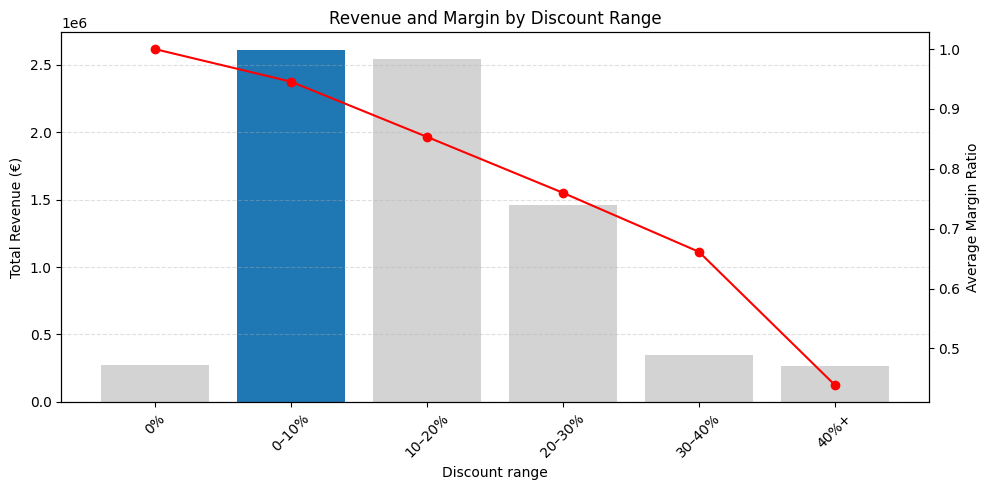

In [ ]:
import matplotlib.pyplot as plt

# Order of the discount ranges
order = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]

# Aggregated df
plot_df = discount_impact.set_index("discount_range").loc[order].reset_index()

# Data as lists
x_labels = plot_df["discount_range"].tolist()
revenue = plot_df["Total_Revenue"].tolist()
margin = plot_df["Avg_Margin_Ratio"].tolist()

# Colors: 0–10% in blue, all the other in grey
bar_colors = ["lightgrey"] * len(x_labels)
bar_colors[x_labels.index("0–10%")] = "tab:blue"

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars = Revenue
ax1.bar(x_labels, revenue, color=bar_colors)
ax1.set_xlabel("Discount range")
ax1.set_ylabel("Total Revenue (€)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Line = Margin (in red)
ax2 = ax1.twinx()
ax2.plot(x_labels, margin, marker="o", color="red")
ax2.set_ylabel("Average Margin Ratio")

plt.title("Revenue and Margin by Discount Range")
plt.tight_layout()
plt.show()


# 5. Seasonal Performance

How do seasonality and special dates (Christmas, Black Friday) affect sales?

To answer this question, we analyze:

📆 Sales trends over time (monthly evolution)

💰 Revenue, not just the number of orders

🔥 Key periods, including:

normal business periods

promotional periods

low-activity periods (post-holiday slowdown)

👉 This approach allows us to clearly identify how seasonality and special dates impact sales performance.

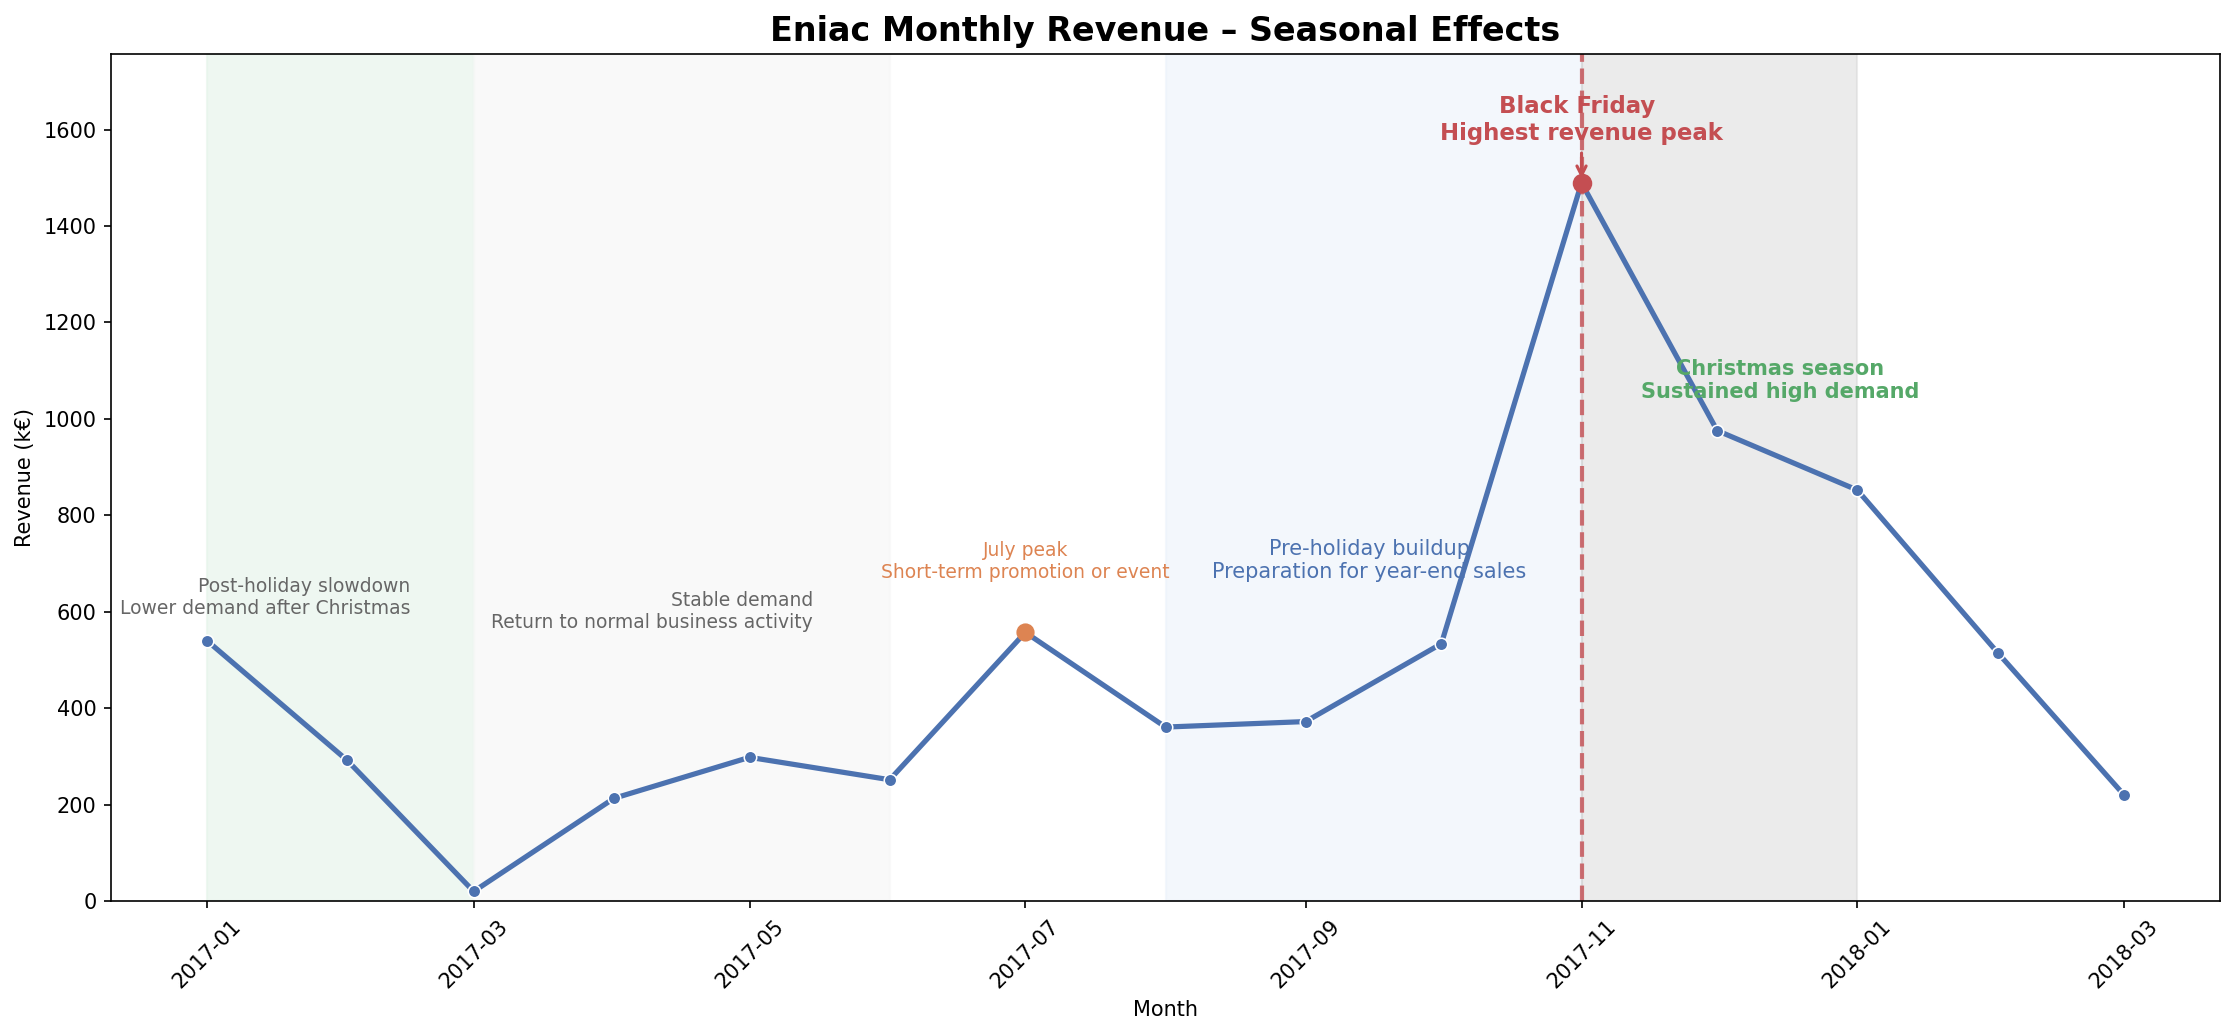

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# 1) Monthly revenue
Eniac_monthly_revenue = (
    sales_df
    .groupby("month")["revenue"]
    .sum()
    .round(1)
    .reset_index()
)

# 2) Convert month to datetime
Eniac_monthly_revenue["month"] = pd.to_datetime(
    Eniac_monthly_revenue["month"].astype(str) + "-01",
    errors="coerce"
)
Eniac_monthly_revenue = Eniac_monthly_revenue.dropna(subset=["month"]).sort_values("month")

T = pd.Timestamp
ymax = Eniac_monthly_revenue["revenue"].max()

# 3) Plot — bigger & sharper
plt.figure(figsize=(15, 7), dpi=150)

sns.lineplot(
    data=Eniac_monthly_revenue,
    x="month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#4C72B0"
)

# Give vertical space for annotations
plt.ylim(0, ymax * 1.18)

# --- Seasonal zones (better calibrated: full month coverage) ---
# (on met la fin au 1er du mois suivant pour couvrir le mois entier)

# Jan–Mar
plt.axvspan(T("2017-01-01"), T("2017-03-01"), color="#e6f4ea", alpha=0.65)
plt.text(
    T("2017-02-15"), ymax * 0.40,
    "Post-holiday slowdown\nLower demand after Christmas",
    ha="right", fontsize=9, color="#666666"
)

# Apr–Jun
plt.axvspan(T("2017-03-01"), T("2017-06-01"), color="#f7f7f7", alpha=0.65)
plt.text(
    T("2017-05-15"), ymax * 0.38,
    "Stable demand\nReturn to normal business activity",
    ha="right", fontsize=9, color="#666666"
)

# Aug–Oct
plt.axvspan(T("2017-08-01"), T("2017-11-01"), color="#eaf2fb", alpha=0.55)
plt.text(
    T("2017-09-15"), ymax * 0.45,
    "Pre-holiday buildup\nPreparation for year-end sales",
    ha="center", fontsize=10, color="#4C72B0"
)

# --- July peak (same annotation text, but peak highlighted) ---
jul_month = T("2017-07-01")
jul_row = Eniac_monthly_revenue.loc[Eniac_monthly_revenue["month"] == jul_month, "revenue"]
if len(jul_row) > 0:
    jul_value = jul_row.values[0]
    # highlight peak (vertical line + point)

    plt.scatter([jul_month], [jul_value], color="#DD8452", zorder=5, s=60)

plt.text(
    T("2017-07-01"), ymax * 0.45,
    "July peak\nShort-term promotion or event",
    ha="center", fontsize=9, color="#DD8452"
)

# --- Black Friday (same annotation text, but period + peak strongly highlighted) ---
bf_month = T("2017-11-01")

# Band just for November (BF / Cyber Monday window)
plt.axvspan(T("2017-11-01"), T("2017-11-01"), color="lightgrey", alpha=0.45)

bf_row = Eniac_monthly_revenue.loc[
    Eniac_monthly_revenue["month"] == bf_month, "revenue"
]
if len(bf_row) > 0:
    bf_value = bf_row.values[0]
    # highlight peak (vertical line + point)
    plt.axvline(bf_month, color="#C44E52", linestyle="--", alpha=0.8, linewidth=2)
    plt.scatter([bf_month], [bf_value], color="#C44E52", zorder=6, s=70)

    plt.annotate(
        "Black Friday \nHighest revenue peak",
        xy=(bf_month, bf_value),
        xytext=(bf_month, ymax * 1.06),
        ha="center",
        fontsize=11,
        color="#C44E52",
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.5)
    )

# --- Christmas season (same text, but clearer seasonal band) ---
plt.axvspan(T("2017-11-01"), T("2018-01-01"), color="lightgrey", alpha=0.45)
plt.text(
    T("2017-12-15"), ymax * 0.70,
    "Christmas season\nSustained high demand",
    ha="center", fontsize=10, color="#55A868", fontweight="bold"
)

# --- Formatting ---
plt.title("Eniac Monthly Revenue – Seasonal Effects", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (k€)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

